# 0.01 BTC footprint tracker — BTC-PYUSD (live)

Port of `test_scripts/tracker.py`, rewritten for the **actual** DEPTH frame format
(the old script parsed levels as arrays; the feed sends dicts:
`{"price": "63939", "qty": "0.01", "order_count": "1", "last_update": "<ns>"}`,
with `qty: "0"` meaning the level was removed).

Follows every order of **exactly 0.01 BTC on either side** of the book and redraws
a live dashboard as events arrive: a timeline of when each footprint was posted
and pulled (price relative to mid), plus lifespan and mid-offset distributions
that fill in as orders close. All event times come from the exchange's own
nanosecond `last_update` stamps, so timing precision does not depend on local
receive jitter.

Speed choices:
- `orjson` for parsing (falls back to stdlib `json`)
- websocket compression disabled (skips permessage-deflate per frame)
- the receive loop only mutates dicts/lists; redrawing happens on a separate
  timer (`REFRESH_S`, default 1s) so plotting cost doesn't sit in the per-message
  path — set `live=False` in `run_tracker(...)` to skip the dashboard entirely
  for max-speed data collection, and `VERBOSE = True` for per-event prints

Resilience: the exchange can drop the connection mid-session without a clean
close frame. `run_tracker` catches that, discards the (unknowable) state of any
footprints that were active at the moment of the drop, and reconnects with
exponential backoff (1s → 15s cap) — the session keeps running for the full
`duration_s` and the reconnect count shows in the dashboard header.

Run order: setup → engine → dashboard → runner → `await run_tracker(...)` → stats.
Interrupt the run cell to stop early; collected data is kept.

In [1]:
import asyncio, json, time
import websockets

try:
    from orjson import loads          # fastest available JSON parser
except ImportError:
    from json import loads

WS_URL     = "wss://api.truex.co/api/v1"
ITEM       = "BTC-PYUSD"
TARGET_QTY = 0.01                     # follow orders of exactly 0.01 BTC, both sides
QTY_EPS    = 1e-9
VERBOSE    = False                    # per-event prints; the live dashboard covers this
REFRESH_S  = 1.0                      # dashboard redraw interval while live

HEADERS = {
    "Origin": "https://truemarkets.co",
    "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/149.0.0.0 Safari/537.36"),
}

In [2]:
# --- shared state, read by the dashboard/stats cells during and after a run ---
book        = {"bid": {}, "ask": {}}   # side -> {price: qty}
active      = {}                       # (side, price) -> open 0.01 footprint
orders      = []                       # closed (and, after finalize, still-open) footprints
mid_history = []                       # (t_exchange_ns, mid)
lat_ns      = []                       # exchange->local latency per UPDATE frame (incl. clock skew)
t0_ns       = None                     # session start on the exchange clock
reconnects  = 0                        # how many times the socket dropped and was re-established


def process_frame(raw, local_ns):
    global t0_ns
    msg = loads(raw)
    channel = msg.get("channel")
    if channel != "DEPTH":
        if channel == "WEBSOCKET" and t0_ns is None:
            t0_ns = int(msg["timestamp"])
        return
    data = msg.get("data")
    if data is None:                   # SNAPSHOT_COMPLETE marker frame
        return
    snapshot = msg["update"] == "SNAPSHOT"

    newest = 0
    created = []
    n_closed = len(orders)
    for side, levels in (("bid", data.get("bids") or ()), ("ask", data.get("asks") or ())):
        lvls = book[side]
        for lv in levels:
            px, qty, t_ex = float(lv["price"]), float(lv["qty"]), int(lv["last_update"])
            if t_ex > newest:
                newest = t_ex
            if qty:
                lvls[px] = qty
            else:
                lvls.pop(px, None)

            key = (side, px)
            hit = abs(qty - TARGET_QTY) < QTY_EPS
            if hit and key not in active:
                rec = {"side": side, "price": px, "t_create": t_ex,
                       "mid_create": None, "preexisting": snapshot}
                active[key] = rec
                created.append(rec)
            elif not hit and key in active:
                rec = active.pop(key)
                rec["t_delete"] = t_ex
                rec["mid_delete"] = None
                rec["reason"] = "cancelled" if qty == 0.0 else "resized"
                orders.append(rec)

    # refresh mid if the book supports it; otherwise fall back to the last known
    # value so a momentarily one-sided book (e.g. right after a reconnect) still
    # lets this frame's events get stamped instead of stuck at None forever
    bids, asks = book["bid"], book["ask"]
    if bids and asks:
        mid = (max(bids) + min(asks)) / 2.0
        if not mid_history or mid_history[-1][1] != mid:
            mid_history.append((newest, mid))
        if not snapshot and newest:
            lat_ns.append(local_ns - newest)
    else:
        mid = mid_history[-1][1] if mid_history else None

    for rec in created:
        rec["mid_create"] = mid
        if VERBOSE and not snapshot and mid is not None:
            dt = (rec["t_create"] - t0_ns) / 1e9 if t0_ns else 0.0
            print(f"[+] {dt:9.3f}s  0.01 {rec['side']:<3} posted @ {rec['price']:>10,.1f}"
                  f"  (mid {rec['price'] - mid:+,.1f})")
    for rec in orders[n_closed:]:
        rec["mid_delete"] = mid
        if VERBOSE:
            dt = (rec["t_delete"] - t0_ns) / 1e9 if t0_ns else 0.0
            life_ms = (rec["t_delete"] - rec["t_create"]) / 1e6
            print(f"[-] {dt:9.3f}s  0.01 {rec['side']:<3} {rec['reason']:<9} @ "
                  f"{rec['price']:>10,.1f}  lived {life_ms:,.1f} ms")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

BID_C, ASK_C = "#2a78d6", "#e34948"          # categorical slots 1 & 6, CVD-validated
INK, MUTED, GRID_C = "#3a3a3a", "#6f6f6f", "#e8e8e8"

def _style(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(True, color=GRID_C, linewidth=0.8)
    ax.set_axisbelow(True)

fig, axd = plt.subplot_mosaic(
    [["timeline", "timeline"], ["life", "off"]],
    figsize=(12, 8), dpi=110, gridspec_kw={"height_ratios": [2, 1]},
)
plt.close(fig)   # keep it out of normal cell auto-display; the runner shows it explicitly


def _draw():
    """Redraw the whole dashboard from current global state. Safe to call anytime."""
    ax_t, ax_l, ax_o = axd["timeline"], axd["life"], axd["off"]
    for ax in (ax_t, ax_l, ax_o):
        ax.clear()

    closed = [r for r in orders if r["reason"] != "open" and r["mid_create"] is not None]
    open_now = [dict(r, reason="open") for r in active.values() if r["mid_create"] is not None]
    recs = [r for r in orders if r["mid_create"] is not None] + open_now

    if recs and mid_history:
        t_end = (mid_history[-1][0] - t0_ns) / 1e9
        mid_end = mid_history[-1][1]
        for r in recs:
            c = BID_C if r["side"] == "bid" else ASK_C
            x0 = max(0.0, (r["t_create"] - t0_ns) / 1e9)
            y0 = r["price"] - r["mid_create"]
            still_open = r["reason"] == "open"
            if still_open:
                x1, y1 = t_end, r["price"] - mid_end
            else:
                x1, y1 = (r["t_delete"] - t0_ns) / 1e9, r["price"] - r["mid_delete"]
            ax_t.plot([x0, x1], [y0, y1], color=c, linewidth=2, alpha=0.8,
                      linestyle=":" if still_open else "-", solid_capstyle="round")
            ax_t.plot([x0], [y0], marker="o", ms=6, mec=c, mew=1.5,
                      mfc="white" if r["preexisting"] else c)
            if not still_open:
                ax_t.plot([x1], [y1], marker="x", ms=7, color=c, mew=2)
        ax_t.axhline(0, color=MUTED, linewidth=1, linestyle="--")
        ax_t.text(0.997, 0, "mid", transform=ax_t.get_yaxis_transform(),
                  ha="right", va="bottom", fontsize=9, color=MUTED)
        handles = [plt.Line2D([], [], color=BID_C, lw=2, label="bid side"),
                   plt.Line2D([], [], color=ASK_C, lw=2, label="ask side")]
        ax_t.legend(handles=handles, frameon=False, loc="upper right", fontsize=9,
                    labelcolor=INK)
    else:
        ax_t.text(0.5, 0.5, "waiting for the first 0.01 order\u2026", ha="center",
                  va="center", transform=ax_t.transAxes, fontsize=11, color=MUTED)
        ax_t.set_xticks([]); ax_t.set_yticks([])
    ax_t.set_xlabel("seconds since connect", color=INK, fontsize=10)
    ax_t.set_ylabel(f"price \u2212 mid ({ITEM.split('-')[1]})", color=INK, fontsize=10)
    ax_t.set_title("0.01 BTC orders: when posted, when pulled, distance from mid",
                   color=INK, fontsize=12, loc="left")

    if closed:
        life = {s: np.array([(r["t_delete"] - r["t_create"]) / 1e6
                             for r in closed if r["side"] == s]) for s in ("bid", "ask")}
        lo = max(0.1, min((v.min() for v in life.values() if len(v)), default=1))
        hi = max((v.max() for v in life.values() if len(v)), default=10)
        bins = np.logspace(np.log10(lo), np.log10(hi * 1.05), 25)
        for side, c in (("bid", BID_C), ("ask", ASK_C)):
            if len(life[side]):
                ax_l.hist(life[side], bins=bins, histtype="step", lw=2, color=c, label=side)
        ax_l.set_xscale("log")
        ax_l.legend(frameon=False, fontsize=9, labelcolor=INK)
    else:
        ax_l.text(0.5, 0.5, "no closed orders yet", ha="center", va="center",
                  transform=ax_l.transAxes, fontsize=10, color=MUTED)
        ax_l.set_xticks([]); ax_l.set_yticks([])
    ax_l.set_xlabel("lifespan (ms, log)", color=INK, fontsize=9)
    ax_l.set_ylabel("orders", color=INK, fontsize=9)
    ax_l.set_title("How long a 0.01 order lives", color=INK, fontsize=10, loc="left")

    if closed:
        off = {s: np.array([r["price"] - r["mid_create"]
                            for r in closed if r["side"] == s]) for s in ("bid", "ask")}
        for side, c in (("bid", BID_C), ("ask", ASK_C)):
            if len(off[side]):
                ax_o.hist(off[side], bins=20, histtype="step", lw=2, color=c, label=side)
        ax_o.axvline(0, color=MUTED, linewidth=1, linestyle="--")
        ax_o.legend(frameon=False, fontsize=9, labelcolor=INK)
    else:
        ax_o.text(0.5, 0.5, "no closed orders yet", ha="center", va="center",
                  transform=ax_o.transAxes, fontsize=10, color=MUTED)
        ax_o.set_xticks([]); ax_o.set_yticks([])
    ax_o.set_xlabel(f"offset from mid at post ({ITEM.split('-')[1]})", color=INK, fontsize=9)
    ax_o.set_ylabel("orders", color=INK, fontsize=9)
    ax_o.set_title("How far from mid they quote", color=INK, fontsize=10, loc="left")

    for ax in (ax_t, ax_l, ax_o):
        _style(ax)
    for ax in (ax_l, ax_o):
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    reconn_note = f"  \u2014  {reconnects} reconnect(s)" if reconnects else ""
    fig.text(0.01, 0.985, f"{ITEM}  \u2014  {len(orders)} closed / {len(active)} open  "
             f"\u2014  updated {time.strftime('%H:%M:%S')}{reconn_note}",
             color=INK, fontsize=10, ha="left", va="top")
    fig.text(0.01, 0.955, "\u25cf posted (hollow = pre-existing)   "
             "\u2715 pulled   \u22ef still open",
             color=MUTED, fontsize=8.5, ha="left", va="top")

In [4]:
async def run_tracker(duration_s=180, live=True, refresh_s=None):
    """Connect, track 0.01 footprints, and (if live) redraw the dashboard on a timer.

    The redraw runs as a separate task on its own interval so the receive loop
    below never blocks on plotting; only the redraw tick itself pays that cost.

    The exchange can drop the connection mid-session without a clean close frame
    (ConnectionClosedError). That is treated as transient: reconnect with backoff
    and keep going until duration_s elapses, rather than losing the whole run.
    Any 0.01 footprints still "active" at the moment of a drop are discarded
    (not recorded as closed) since their true fate during the gap is unknown; a
    fresh SNAPSHOT after reconnecting re-establishes the book from scratch.
    """
    global t0_ns, reconnects
    book["bid"].clear(); book["ask"].clear()
    active.clear(); orders.clear(); mid_history.clear(); lat_ns.clear()
    t0_ns = None
    reconnects = 0
    frames = 0
    refresh_s = REFRESH_S if refresh_s is None else refresh_s
    deadline = time.monotonic() + duration_s

    handle = None
    redraw_task = None

    async def redraw_loop():
        while True:
            await asyncio.sleep(refresh_s)
            _draw()
            handle.update(fig)

    if live:
        _draw()
        handle = display(fig, display_id=True)
        redraw_task = asyncio.create_task(redraw_loop())

    backoff = 1.0
    try:
        while (left := deadline - time.monotonic()) > 0:
            if reconnects:                  # stale book/active from before the drop;
                book["bid"].clear()         # the incoming SNAPSHOT will redefine both
                book["ask"].clear()
                active.clear()
            try:
                async with websockets.connect(
                    WS_URL, additional_headers=HEADERS,
                    compression=None,       # no permessage-deflate: less work per frame
                    max_queue=2**10,
                ) as ws:
                    await ws.send(json.dumps({
                        "type": "SUBSCRIBE_NO_AUTH",
                        "item_names": [ITEM],
                        "channels": ["DEPTH"],
                        "timestamp": str(int(time.time())),
                    }))
                    backoff = 1.0
                    while (left := deadline - time.monotonic()) > 0:
                        raw = await asyncio.wait_for(ws.recv(), timeout=left)
                        process_frame(raw, time.time_ns())
                        frames += 1
            except (websockets.ConnectionClosed, OSError):
                if time.monotonic() >= deadline:
                    break
                reconnects += 1
                dt = (time.time_ns() - t0_ns) / 1e9 if t0_ns else 0.0
                print(f"[!] {dt:9.3f}s  connection dropped, reconnecting in {backoff:.0f}s "
                      f"(#{reconnects})")
                await asyncio.sleep(backoff)
                backoff = min(backoff * 2, 15.0)
    except (asyncio.TimeoutError, asyncio.CancelledError, KeyboardInterrupt):
        pass
    finally:
        if redraw_task is not None:
            redraw_task.cancel()
            try:
                await redraw_task
            except asyncio.CancelledError:
                pass

    for rec in active.values():        # footprints still on the book at shutdown
        rec["t_delete"] = None
        rec["mid_delete"] = None
        rec["reason"] = "open"
        orders.append(rec)
    active.clear()
    if live and handle is not None:
        _draw()
        handle.update(fig)
    print(f"\n{frames} frames | {reconnects} reconnect(s) | {len(orders)} tracked 0.01 orders "
          f"({sum(r['reason'] == 'open' for r in orders)} still open) | "
          f"{len(mid_history)} mid changes")

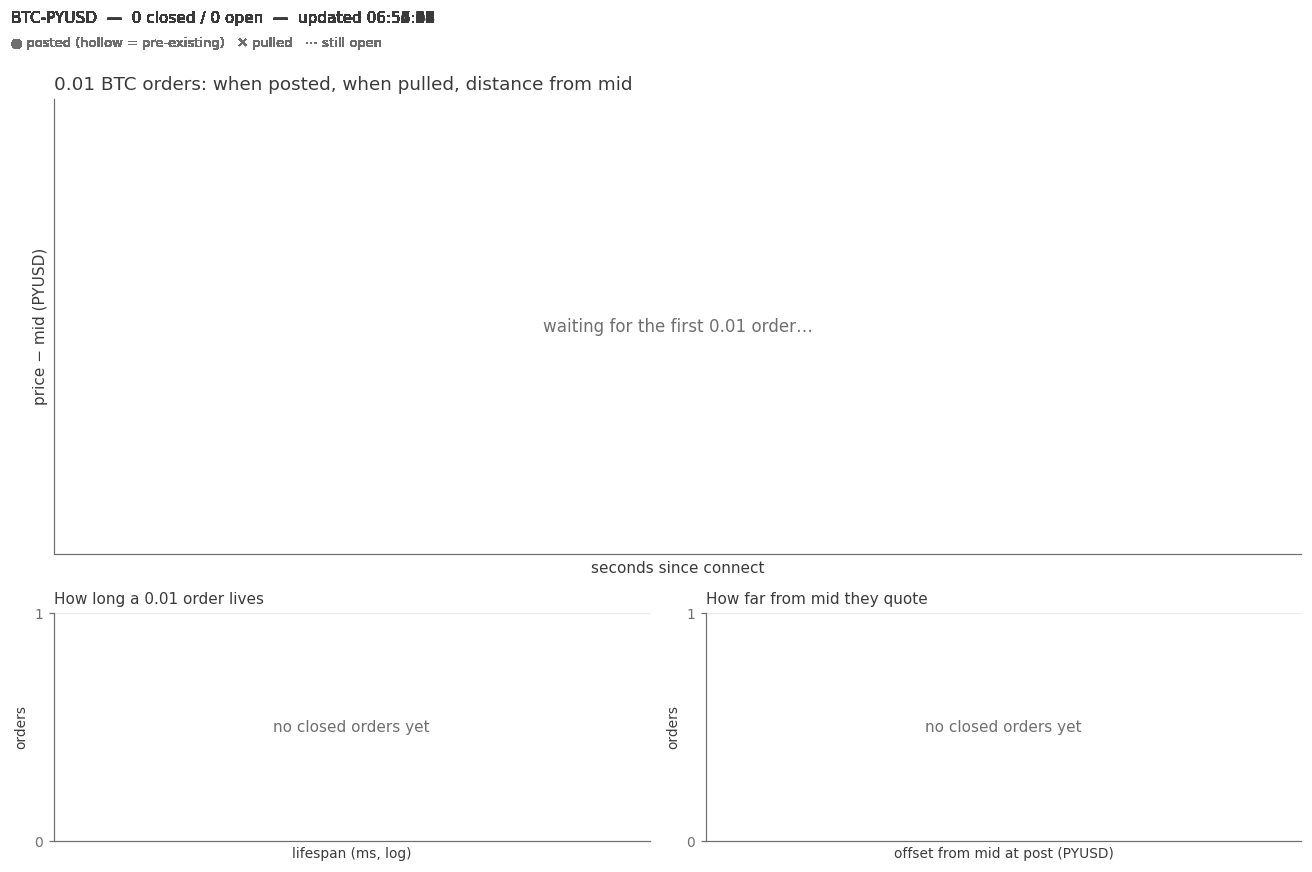


47 frames | 0 reconnect(s) | 0 tracked 0.01 orders (0 still open) | 1 mid changes


In [5]:
await run_tracker()   # interrupt to stop early; data is kept

In [6]:
closed = [r for r in orders if r["reason"] != "open" and r["mid_create"] is not None]
if closed:
    life = np.array([(r["t_delete"] - r["t_create"]) / 1e6 for r in closed])
    print(f"{len(closed)} closed footprints "
          f"({sum(r['side'] == 'bid' for r in closed)} bid / "
          f"{sum(r['side'] == 'ask' for r in closed)} ask)")
    print(f"lifespan ms   p10 {np.percentile(life, 10):>10,.1f}   "
          f"median {np.median(life):>10,.1f}   p90 {np.percentile(life, 90):>10,.1f}")
    for side in ("bid", "ask"):
        off = np.array([r["price"] - r["mid_create"]
                        for r in closed if r["side"] == side])
        if len(off):
            print(f"{side} offset from mid at post: median {np.median(off):+,.1f}  "
                  f"range [{off.min():+,.1f}, {off.max():+,.1f}]")
else:
    print("no closed 0.01 footprints recorded yet")
if lat_ns:
    lat = np.array(lat_ns) / 1e6
    print(f"feed latency exchange->local (incl. clock skew): "
          f"median {np.median(lat):,.1f} ms   p90 {np.percentile(lat, 90):,.1f} ms")

no closed 0.01 footprints recorded yet
feed latency exchange->local (incl. clock skew): median 383.3 ms   p90 1,010.5 ms
